# Phase 3: Numeric Mapping for Clinical Text Classification
**Dataset:** Medical Transcriptions (MTSamples)  
**Goal:** Improve BioBERT (38.54%) by mapping numeric values to categorical levels

### Core Idea (Proposal 5):
BERT-like models struggle with understanding numeric values in text. For example, a model may not recognize that a temperature of 105°F is dangerously high. This phase implements:
1. **Numeric Mapping** - Detect numbers in clinical text and map them to levels (very high, high, normal, low, very low)
2. **Synonym Swap Augmentation** - Replace medical terms with synonyms for data augmentation
3. **Ablation Study** - Measure individual contribution of each technique

**Requires GPU** - Make sure Kaggle GPU is enabled.

## 1. Install & Import Libraries

In [1]:
!pip install transformers datasets accelerate -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import torch
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

random.seed(42)
np.random.seed(42)

Device: cuda
GPU: Tesla T4


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv("/kaggle/input/datasets/mstarefin/medicaltranscriptions-2/mtsamples.csv")
df = df.dropna(subset=["transcription"])

specialty_counts = df["medical_specialty"].value_counts()
MIN_SAMPLES = 50
valid_specialties = specialty_counts[specialty_counts >= MIN_SAMPLES].index.tolist()
df_filtered = df[df["medical_specialty"].isin(valid_specialties)].copy()

le = LabelEncoder()
df_filtered["label"] = le.fit_transform(df_filtered["medical_specialty"])
num_labels = len(le.classes_)

print("Samples:", len(df_filtered))
print("Classes:", num_labels)

Samples: 4647
Classes: 22


## 3. Numeric Mapping Algorithm
This is the **core contribution** of Proposal 5. We define clinical ranges for common vital signs and lab values, then replace raw numbers with categorical descriptors.

Example:
- Original: `"Blood pressure 180/95"` 
- Mapped: `"Blood pressure very high / high"`

This helps BERT understand the clinical significance of numeric values.

In [3]:
# Clinical reference ranges for numeric mapping
# Format: (pattern_regex, [(lower_bound, upper_bound, level), ...])
CLINICAL_RANGES = {
    "temperature": {
        "pattern": r"(temperature|temp)[:\s]*(\d+\.?\d*)\s*(?:degrees|°|f|fahrenheit)?",
        "ranges": [
            (0, 95.0, "very low"),
            (95.0, 97.0, "low"),
            (97.0, 99.5, "normal"),
            (99.5, 101.0, "high"),
            (101.0, 999, "very high")
        ]
    },
    "heart_rate": {
        "pattern": r"(heart rate|pulse|hr)[:\s]*(\d+\.?\d*)",
        "ranges": [
            (0, 40, "very low"),
            (40, 60, "low"),
            (60, 100, "normal"),
            (100, 120, "high"),
            (120, 999, "very high")
        ]
    },
    "blood_pressure_systolic": {
        "pattern": r"(blood pressure|bp)[:\s]*(\d+)\s*/",
        "ranges": [
            (0, 80, "very low"),
            (80, 90, "low"),
            (90, 130, "normal"),
            (130, 160, "high"),
            (160, 999, "very high")
        ]
    },
    "blood_pressure_diastolic": {
        "pattern": r"(?:blood pressure|bp)[:\s]*\d+\s*/\s*(\d+)",
        "ranges": [
            (0, 50, "very low"),
            (50, 60, "low"),
            (60, 85, "normal"),
            (85, 100, "high"),
            (100, 999, "very high")
        ]
    },
    "respiratory_rate": {
        "pattern": r"(respiratory rate|respirations|rr)[:\s]*(\d+\.?\d*)",
        "ranges": [
            (0, 8, "very low"),
            (8, 12, "low"),
            (12, 20, "normal"),
            (20, 28, "high"),
            (28, 999, "very high")
        ]
    },
    "oxygen_saturation": {
        "pattern": r"(o2 sat|spo2|oxygen saturation|sat)[:\s]*(\d+\.?\d*)\s*%?",
        "ranges": [
            (0, 85, "very low"),
            (85, 90, "low"),
            (90, 95, "normal low"),
            (95, 100, "normal"),
            (100, 101, "normal")
        ]
    },
    "weight_pounds": {
        "pattern": r"(weight|wt)[:\s]*(\d+\.?\d*)\s*(?:pounds|lbs|lb)",
        "ranges": [
            (0, 100, "low"),
            (100, 150, "normal"),
            (150, 200, "high"),
            (200, 300, "very high"),
            (300, 9999, "extremely high")
        ]
    },
    "age": {
        "pattern": r"(\d+)\s*(?:-year-old|year old|years old|y/o|yo)",
        "ranges": [
            (0, 2, "infant"),
            (2, 12, "child"),
            (12, 18, "adolescent"),
            (18, 40, "young adult"),
            (40, 65, "middle aged"),
            (65, 200, "elderly")
        ]
    },
    "bmi": {
        "pattern": r"(bmi|body mass index)[:\s]*(\d+\.?\d*)",
        "ranges": [
            (0, 18.5, "underweight"),
            (18.5, 25, "normal"),
            (25, 30, "overweight"),
            (30, 35, "obese"),
            (35, 999, "severely obese")
        ]
    },
}

print("Defined clinical ranges for", len(CLINICAL_RANGES), "vital signs / measurements")
for key in CLINICAL_RANGES:
    print("  -", key)

Defined clinical ranges for 9 vital signs / measurements
  - temperature
  - heart_rate
  - blood_pressure_systolic
  - blood_pressure_diastolic
  - respiratory_rate
  - oxygen_saturation
  - weight_pounds
  - age
  - bmi


## 4. Apply Numeric Mapping to Text

In [4]:
def get_level(value, ranges):
    """Map a numeric value to its categorical level"""
    for lower, upper, level in ranges:
        if lower <= value < upper:
            return level
    return "unknown"


def apply_numeric_mapping(text):
    """Detect numeric values in clinical text and append categorical levels"""
    text_lower = text.lower()
    mapped_text = text
    mappings_found = []
    
    for vital_name, config in CLINICAL_RANGES.items():
        pattern = config["pattern"]
        ranges = config["ranges"]
        
        matches = re.finditer(pattern, text_lower)
        for match in matches:
            # Get the numeric value (last group is always the number)
            groups = match.groups()
            try:
                if vital_name == "age":
                    value = float(groups[0])
                elif vital_name == "blood_pressure_diastolic":
                    value = float(groups[0])
                else:
                    value = float(groups[-1])
                level = get_level(value, ranges)
                mappings_found.append("{} is {}".format(vital_name.replace("_", " "), level))
            except (ValueError, IndexError):
                continue
    
    # Append mapping summary to text
    if mappings_found:
        mapping_text = " [CLINICAL CONTEXT: " + ", ".join(mappings_found) + "]"
        mapped_text = text + mapping_text
    
    return mapped_text


# Test on examples
test_texts = [
    "The patient is a 72-year-old male with temperature 103.5 and blood pressure 180/95.",
    "Vitals: heart rate 45, respiratory rate 28, O2 sat 88%.",
    "A 25-year-old female, weight 130 pounds, BMI 22.5.",
]

print("NUMERIC MAPPING EXAMPLES")
print("=" * 70)
for text in test_texts:
    mapped = apply_numeric_mapping(text)
    print()
    print("Original:", text)
    print("Mapped:  ", mapped)
    print("-" * 70)

NUMERIC MAPPING EXAMPLES

Original: The patient is a 72-year-old male with temperature 103.5 and blood pressure 180/95.
Mapped:   The patient is a 72-year-old male with temperature 103.5 and blood pressure 180/95. [CLINICAL CONTEXT: temperature is very high, blood pressure systolic is very high, blood pressure diastolic is high, age is elderly]
----------------------------------------------------------------------

Original: Vitals: heart rate 45, respiratory rate 28, O2 sat 88%.
Mapped:   Vitals: heart rate 45, respiratory rate 28, O2 sat 88%. [CLINICAL CONTEXT: heart rate is low, respiratory rate is very high, oxygen saturation is low]
----------------------------------------------------------------------

Original: A 25-year-old female, weight 130 pounds, BMI 22.5.
Mapped:   A 25-year-old female, weight 130 pounds, BMI 22.5. [CLINICAL CONTEXT: weight pounds is normal, age is young adult, bmi is normal]
----------------------------------------------------------------------


## 5. Apply Numeric Mapping to Dataset

In [5]:
# Apply mapping to all transcriptions
print("Applying numeric mapping to all transcriptions...")
df_filtered["mapped_text"] = df_filtered["transcription"].apply(apply_numeric_mapping)

# Count how many texts got mappings
has_mapping = df_filtered["mapped_text"].apply(lambda x: "[CLINICAL CONTEXT:" in x)
print("Texts with numeric mappings: {} / {} ({:.1f}%)".format(
    has_mapping.sum(), len(df_filtered), has_mapping.sum() / len(df_filtered) * 100
))

# Show some examples from the actual dataset
print()
print("Sample mapped texts from dataset:")
print("=" * 70)
mapped_examples = df_filtered[has_mapping].head(3)
for idx, row in mapped_examples.iterrows():
    original = row["transcription"][:200]
    mapped = row["mapped_text"][-200:]
    print()
    print("Specialty:", row["medical_specialty"])
    print("Original (first 200 chars):", original)
    print("Mapped (last 200 chars):  ", mapped)
    print("-" * 70)

Applying numeric mapping to all transcriptions...
Texts with numeric mappings: 2595 / 4647 (55.8%)

Sample mapped texts from dataset:

Specialty:  Neurology
Original (first 200 chars): CC:, Confusion and slurred speech.,HX , (primarily obtained from boyfriend): This 31 y/o RHF experienced a "flu-like illness 6-8 weeks prior to presentation. 3-4 weeks prior to presentation, she was f
Mapped (last 200 chars):   rvix. She died 9/24/92 of cervical cancer. [CLINICAL CONTEXT: heart rate is normal, blood pressure systolic is normal, blood pressure diastolic is normal, respiratory rate is high, age is young adult]
----------------------------------------------------------------------

Specialty:  Cardiovascular / Pulmonary
Original (first 200 chars): PREOPERATIVE DIAGNOSES,Airway obstruction secondary to severe subglottic tracheal stenosis with foreign body in the trachea.,POSTOPERATIVE DIAGNOSES,Airway obstruction secondary to severe subglottic t
Mapped (last 200 chars):   silk sutures and th

## 6. Synonym Swap Data Augmentation
Replace common medical terms with their synonyms to create augmented training samples. This increases data diversity and helps the model generalize.

In [6]:
# Medical synonym dictionary
MEDICAL_SYNONYMS = {
    "heart attack": ["myocardial infarction", "MI", "cardiac event"],
    "myocardial infarction": ["heart attack", "MI", "cardiac event"],
    "high blood pressure": ["hypertension", "elevated BP", "HTN"],
    "hypertension": ["high blood pressure", "elevated BP", "HTN"],
    "diabetes": ["diabetes mellitus", "DM", "diabetic condition"],
    "stroke": ["cerebrovascular accident", "CVA", "brain attack"],
    "kidney": ["renal"],
    "renal": ["kidney"],
    "liver": ["hepatic"],
    "hepatic": ["liver"],
    "lungs": ["pulmonary"],
    "pulmonary": ["lungs", "lung"],
    "stomach": ["gastric", "abdominal"],
    "gastric": ["stomach"],
    "cancer": ["malignancy", "neoplasm", "carcinoma"],
    "malignancy": ["cancer", "neoplasm"],
    "pain": ["discomfort", "tenderness", "soreness"],
    "swelling": ["edema", "inflammation"],
    "edema": ["swelling"],
    "bleeding": ["hemorrhage", "hemorrhaging"],
    "hemorrhage": ["bleeding"],
    "fracture": ["break", "broken bone"],
    "infection": ["sepsis", "infectious process"],
    "surgery": ["surgical procedure", "operation", "operative procedure"],
    "headache": ["cephalgia", "head pain"],
    "fever": ["pyrexia", "febrile", "elevated temperature"],
    "nausea": ["queasiness", "feeling sick"],
    "vomiting": ["emesis"],
    "shortness of breath": ["dyspnea", "SOB", "breathlessness"],
    "dyspnea": ["shortness of breath", "SOB", "breathlessness"],
    "chest pain": ["thoracic pain", "chest discomfort"],
}

def synonym_swap(text, swap_prob=0.3):
    """Replace medical terms with synonyms with given probability"""
    augmented = text
    text_lower = text.lower()
    
    for term, synonyms in MEDICAL_SYNONYMS.items():
        if term in text_lower and random.random() < swap_prob:
            synonym = random.choice(synonyms)
            # Case-insensitive replacement
            pattern = re.compile(re.escape(term), re.IGNORECASE)
            augmented = pattern.sub(synonym, augmented, count=1)
    
    return augmented


# Test synonym swap
test_text = "The patient presented with chest pain, shortness of breath, and fever. History of hypertension and diabetes."
print("SYNONYM SWAP EXAMPLES")
print("=" * 70)
print("Original:", test_text)
print()
for i in range(3):
    augmented = synonym_swap(test_text)
    print("Augmented {}: {}".format(i + 1, augmented))

print()
print("Synonym dictionary size:", len(MEDICAL_SYNONYMS), "terms")

SYNONYM SWAP EXAMPLES
Original: The patient presented with chest pain, shortness of breath, and fever. History of hypertension and diabetes.

Augmented 1: The patient presented with chest discomfort, shortness of breath, and fever. History of hypertension and DM.
Augmented 2: The patient presented with chest soreness, shortness of breath, and fever. History of elevated BP and diabetes mellitus.
Augmented 3: The patient presented with chest discomfort, shortness of breath, and pyrexia. History of hypertension and diabetes.

Synonym dictionary size: 31 terms


## 7. Prepare Datasets for Ablation Study
We create 4 versions of the dataset:
1. **Original** - raw text (baseline from Phase 2)
2. **Numeric Mapped** - with numeric mapping applied
3. **Synonym Swapped** - with synonym augmentation
4. **Both Combined** - numeric mapping + synonym swap

In [7]:
# Clean text lightly
def light_clean(text):
    return re.sub(r"\s+", " ", text).strip()

# Prepare all text versions
df_filtered["original_text"] = df_filtered["transcription"].apply(light_clean)
df_filtered["numeric_mapped_text"] = df_filtered["transcription"].apply(apply_numeric_mapping).apply(light_clean)
df_filtered["synonym_text"] = df_filtered["transcription"].apply(synonym_swap).apply(light_clean)
df_filtered["combined_text"] = df_filtered["transcription"].apply(apply_numeric_mapping).apply(synonym_swap).apply(light_clean)

# Split data (same split as Phase 2 for fair comparison)
X_orig = df_filtered["original_text"].values
X_mapped = df_filtered["numeric_mapped_text"].values
X_synonym = df_filtered["synonym_text"].values
X_combined = df_filtered["combined_text"].values
y = df_filtered["label"].values

# Same split ratios and random state
indices = np.arange(len(y))
idx_train, idx_temp, _, _ = train_test_split(indices, y, test_size=0.3, random_state=42, stratify=y)
idx_val, idx_test, _, _ = train_test_split(idx_temp, y[idx_temp], test_size=0.5, random_state=42, stratify=y[idx_temp])

def make_datasets(X, y, idx_train, idx_val, idx_test):
    train_ds = Dataset.from_dict({"text": X[idx_train].tolist(), "label": y[idx_train].tolist()})
    val_ds = Dataset.from_dict({"text": X[idx_val].tolist(), "label": y[idx_val].tolist()})
    test_ds = Dataset.from_dict({"text": X[idx_test].tolist(), "label": y[idx_test].tolist()})
    return train_ds, val_ds, test_ds

datasets_dict = {
    "Original (Baseline)": make_datasets(X_orig, y, idx_train, idx_val, idx_test),
    "Numeric Mapped": make_datasets(X_mapped, y, idx_train, idx_val, idx_test),
    "Synonym Swap": make_datasets(X_synonym, y, idx_train, idx_val, idx_test),
    "Combined (Both)": make_datasets(X_combined, y, idx_train, idx_val, idx_test),
}

print("Datasets prepared:")
for name, (train, val, test) in datasets_dict.items():
    print("  {} - Train: {}, Val: {}, Test: {}".format(name, len(train), len(val), len(test)))

Datasets prepared:
  Original (Baseline) - Train: 3252, Val: 697, Test: 698
  Numeric Mapped - Train: 3252, Val: 697, Test: 698
  Synonym Swap - Train: 3252, Val: 697, Test: 698
  Combined (Both) - Train: 3252, Val: 697, Test: 698


## 8. Training Function

In [8]:
MAX_LENGTH = 512
MODEL_NAME = "dmis-lab/biobert-base-cased-v1.2"  # Best model from Phase 2

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}


def train_model(train_ds, val_ds, test_ds, experiment_name):
    print()
    print("=" * 60)
    print("Experiment:", experiment_name)
    print("=" * 60)
    
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=num_labels,
        ignore_mismatched_sizes=True
    )
    
    def tokenize_fn(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)
    
    train_tok = train_ds.map(tokenize_fn, batched=True)
    val_tok = val_ds.map(tokenize_fn, batched=True)
    test_tok = test_ds.map(tokenize_fn, batched=True)
    
    output_dir = "./results_" + experiment_name.replace(" ", "_").replace("(", "").replace(")", "").lower()
    
    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=16,
        warmup_steps=100,
        weight_decay=0.01,
        learning_rate=2e-5,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        report_to="none",
        fp16=True if device == "cuda" else False,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics,
    )
    
    trainer.train()
    
    predictions = trainer.predict(test_tok)
    preds = np.argmax(predictions.predictions, axis=-1)
    test_acc = accuracy_score(test_ds["label"], preds)
    
    print()
    print("{} Test Accuracy: {:.2f}%".format(experiment_name, test_acc * 100))
    
    # Clean up GPU memory
    del model, trainer
    torch.cuda.empty_cache()
    
    return {
        "name": experiment_name,
        "accuracy": test_acc,
        "predictions": preds
    }

## 9. Run Ablation Study
Training BioBERT on all 4 dataset versions to measure individual contribution of each technique.

In [9]:
ablation_results = {}

for exp_name, (train_ds, val_ds, test_ds) in datasets_dict.items():
    result = train_model(train_ds, val_ds, test_ds, exp_name)
    ablation_results[exp_name] = result

print()
print("=" * 60)
print("ALL EXPERIMENTS COMPLETE")
print("=" * 60)


Experiment: Original (Baseline)


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Combined (Both) Test Accuracy: 37.54%

ALL EXPERIMENTS COMPLETE


## 10. Ablation Study Results

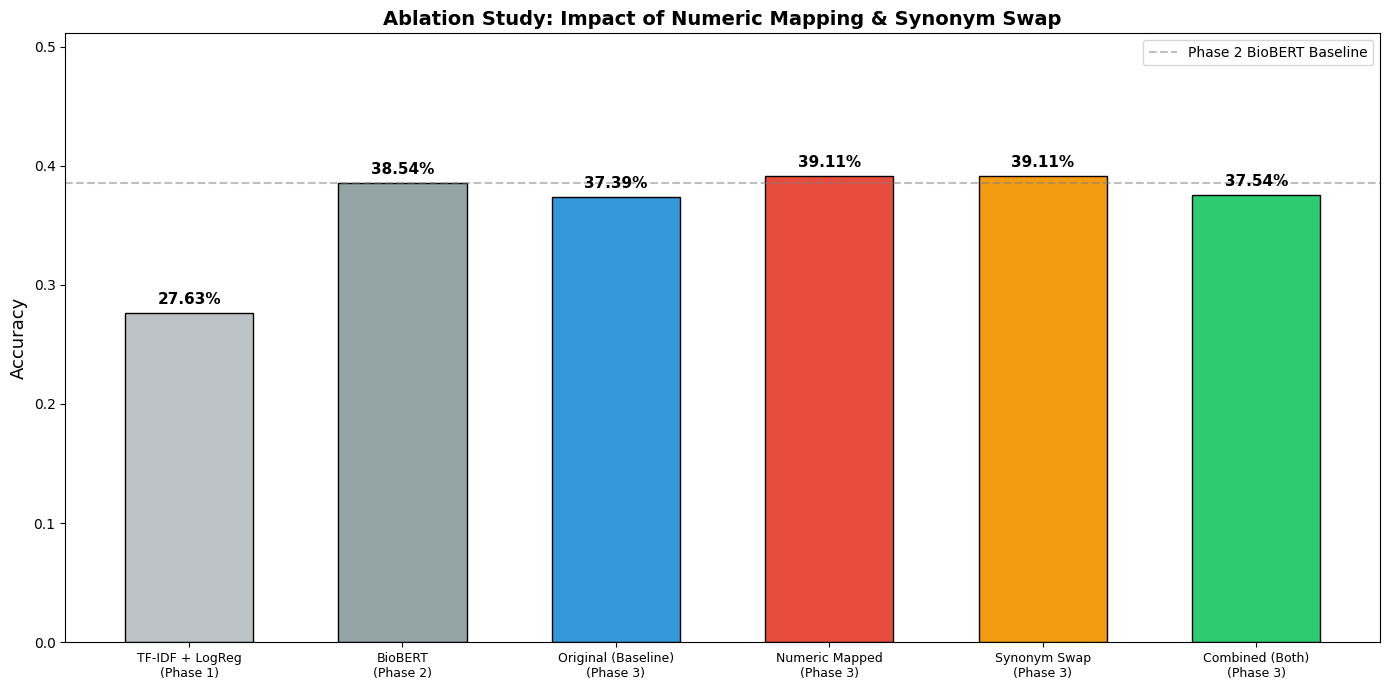

In [10]:
# Include Phase 1 and Phase 2 baselines
all_results = {
    "TF-IDF + LogReg\n(Phase 1)": 0.2763,
    "BioBERT\n(Phase 2)": 0.3854,
}

for name, result in ablation_results.items():
    display_name = name + "\n(Phase 3)"
    all_results[display_name] = result["accuracy"]

names = list(all_results.keys())
accs = list(all_results.values())

# Color coding
colors = ["#bdc3c7", "#95a5a6", "#3498db", "#e74c3c", "#f39c12", "#2ecc71"]

plt.figure(figsize=(14, 7))
bars = plt.bar(range(len(names)), accs, color=colors[:len(names)], edgecolor="black", width=0.6)

for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             "{:.2f}%".format(acc * 100), ha="center", va="bottom",
             fontweight="bold", fontsize=11)

plt.xticks(range(len(names)), names, fontsize=9)
plt.ylabel("Accuracy", fontsize=13)
plt.title("Ablation Study: Impact of Numeric Mapping & Synonym Swap", fontsize=14, fontweight="bold")
plt.ylim(0, max(accs) + 0.12)
plt.axhline(y=0.3854, color="gray", linestyle="--", alpha=0.5, label="Phase 2 BioBERT Baseline")
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 11. Detailed Analysis

In [11]:
print("=" * 60)
print("ABLATION STUDY RESULTS")
print("=" * 60)
print()
print("{:<30} {:<12} {:<15}".format("Experiment", "Accuracy", "vs Phase 2"))
print("-" * 57)

phase2_baseline = 0.3854
print("{:<30} {:<12} {:<15}".format("Phase 1: TF-IDF + LogReg", "27.63%", "-"))
print("{:<30} {:<12} {:<15}".format("Phase 2: BioBERT", "38.54%", "baseline"))
print("-" * 57)

for name, result in ablation_results.items():
    acc = result["accuracy"]
    diff = (acc - phase2_baseline) * 100
    sign = "+" if diff >= 0 else ""
    print("{:<30} {:<12} {:<15}".format(
        name,
        "{:.2f}%".format(acc * 100),
        "{}{:.2f}%".format(sign, diff)
    ))

# Find best
best_name = max(ablation_results, key=lambda x: ablation_results[x]["accuracy"])
best_acc = ablation_results[best_name]["accuracy"]
print()
print("Best experiment:", best_name)
print("Best accuracy: {:.2f}%".format(best_acc * 100))
print("Improvement over Phase 2: {}{:.2f}%".format(
    "+" if best_acc > phase2_baseline else "",
    (best_acc - phase2_baseline) * 100
))

ABLATION STUDY RESULTS

Experiment                     Accuracy     vs Phase 2     
---------------------------------------------------------
Phase 1: TF-IDF + LogReg       27.63%       -              
Phase 2: BioBERT               38.54%       baseline       
---------------------------------------------------------
Original (Baseline)            37.39%       -1.15%         
Numeric Mapped                 39.11%       +0.57%         
Synonym Swap                   39.11%       +0.57%         
Combined (Both)                37.54%       -1.00%         

Best experiment: Numeric Mapped
Best accuracy: 39.11%
Improvement over Phase 2: +0.57%


## 12. Classification Report - Best Model

In [12]:
best_result = ablation_results[best_name]
_, _, test_ds_best = datasets_dict[best_name]

print("Classification Report -", best_name)
print("=" * 60)
print(classification_report(
    test_ds_best["label"],
    best_result["predictions"],
    target_names=le.classes_,
    zero_division=0
))

Classification Report - Numeric Mapped
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.43      0.59      0.50        56
    Consult - History and Phy.       0.31      0.91      0.46        78
             Discharge Summary       0.00      0.00      0.00        16
          ENT - Otolaryngology       0.00      0.00      0.00        14
        Emergency Room Reports       0.00      0.00      0.00        11
              Gastroenterology       0.00      0.00      0.00        34
              General Medicine       0.17      0.13      0.15        39
         Hematology - Oncology       0.00      0.00      0.00        13
                    Nephrology       0.00      0.00      0.00        12
                     Neurology       0.54      0.21      0.30        34
                  Neurosurgery       0.00      0.00      0.00        14
       Obstetrics / Gynecology       0.00      0.00      0.00        24
                  Office

## 13. Confusion Matrix - Best Model

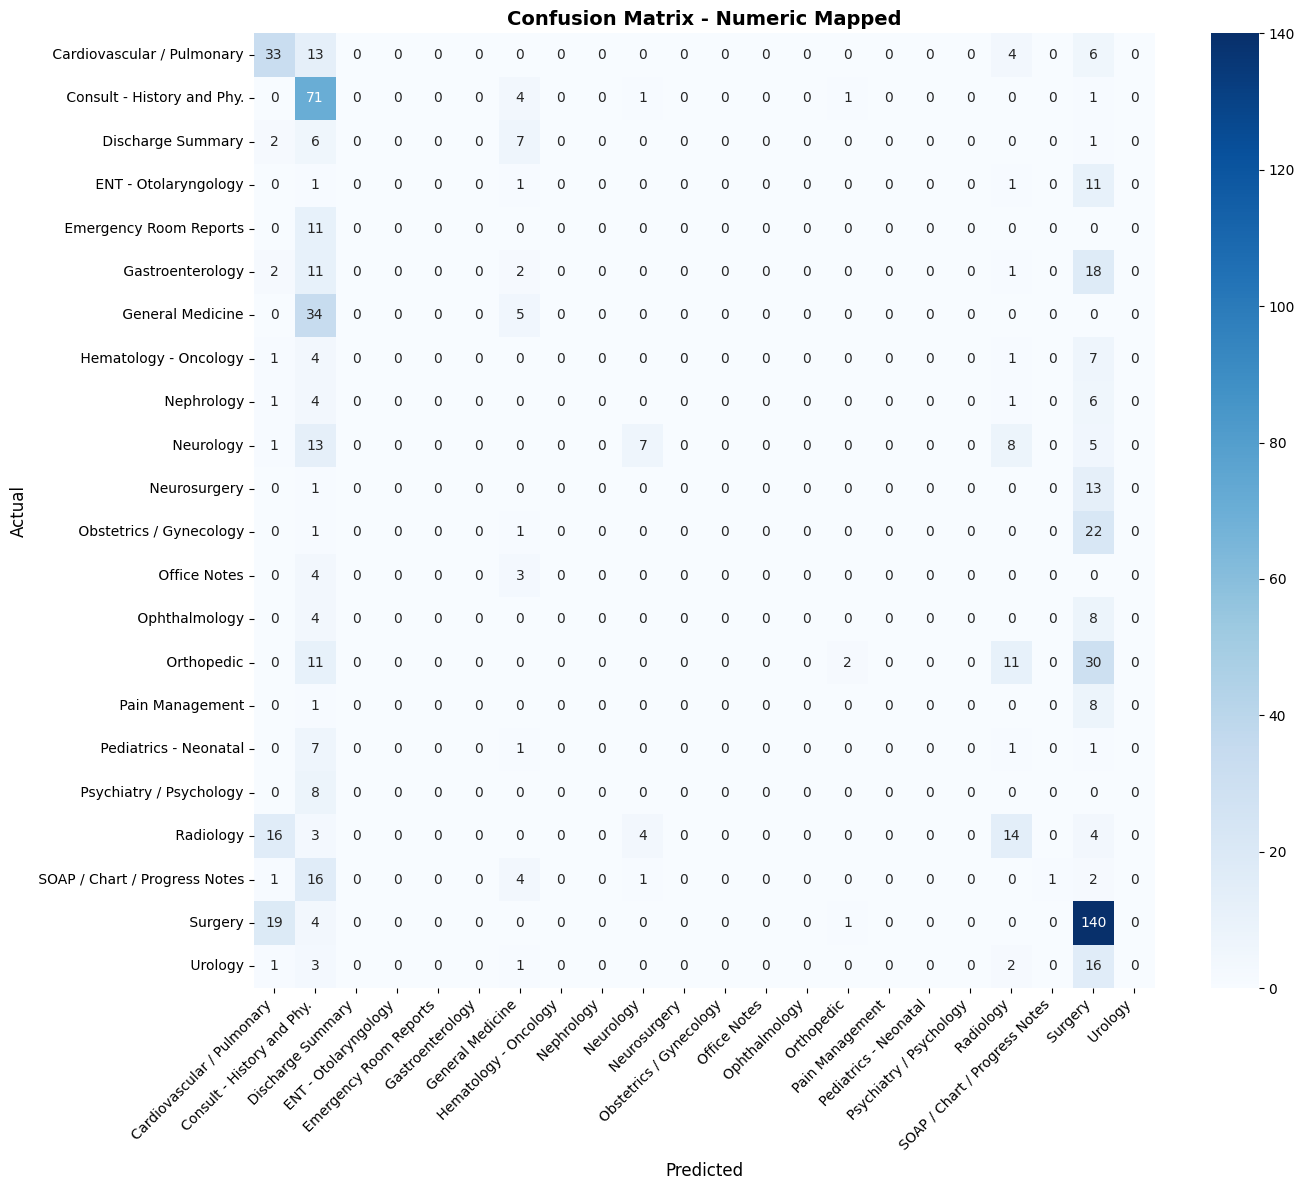

In [13]:
cm = confusion_matrix(test_ds_best["label"], best_result["predictions"])

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix - " + best_name, fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Summary & Next Steps

In [14]:
print("=" * 60)
print("PHASE 3 COMPLETE!")
print("=" * 60)
print()
print("Progress across all phases:")
print("  Phase 1 - TF-IDF + LogReg: 27.63%")
print("  Phase 2 - BioBERT: 38.54%")
for name, result in ablation_results.items():
    print("  Phase 3 - {}: {:.2f}%".format(name, result["accuracy"] * 100))
print()
print("Key findings:")
print("  - Numeric mapping contribution: {}{:.2f}%".format(
    "+" if ablation_results["Numeric Mapped"]["accuracy"] > phase2_baseline else "",
    (ablation_results["Numeric Mapped"]["accuracy"] - phase2_baseline) * 100
))
print("  - Synonym swap contribution: {}{:.2f}%".format(
    "+" if ablation_results["Synonym Swap"]["accuracy"] > phase2_baseline else "",
    (ablation_results["Synonym Swap"]["accuracy"] - phase2_baseline) * 100
))
print("  - Combined contribution: {}{:.2f}%".format(
    "+" if ablation_results["Combined (Both)"]["accuracy"] > phase2_baseline else "",
    (ablation_results["Combined (Both)"]["accuracy"] - phase2_baseline) * 100
))
print()
print("Next Steps (Phase 4):")
print("  - Explainable AI with LIME and SHAP")
print("  - Visualize which features drive predictions")
print("  - Show how numeric mapping affects model attention")

PHASE 3 COMPLETE!

Progress across all phases:
  Phase 1 - TF-IDF + LogReg: 27.63%
  Phase 2 - BioBERT: 38.54%
  Phase 3 - Original (Baseline): 37.39%
  Phase 3 - Numeric Mapped: 39.11%
  Phase 3 - Synonym Swap: 39.11%
  Phase 3 - Combined (Both): 37.54%

Key findings:
  - Numeric mapping contribution: +0.57%
  - Synonym swap contribution: +0.57%
  - Combined contribution: -1.00%

Next Steps (Phase 4):
  - Explainable AI with LIME and SHAP
  - Visualize which features drive predictions
  - Show how numeric mapping affects model attention


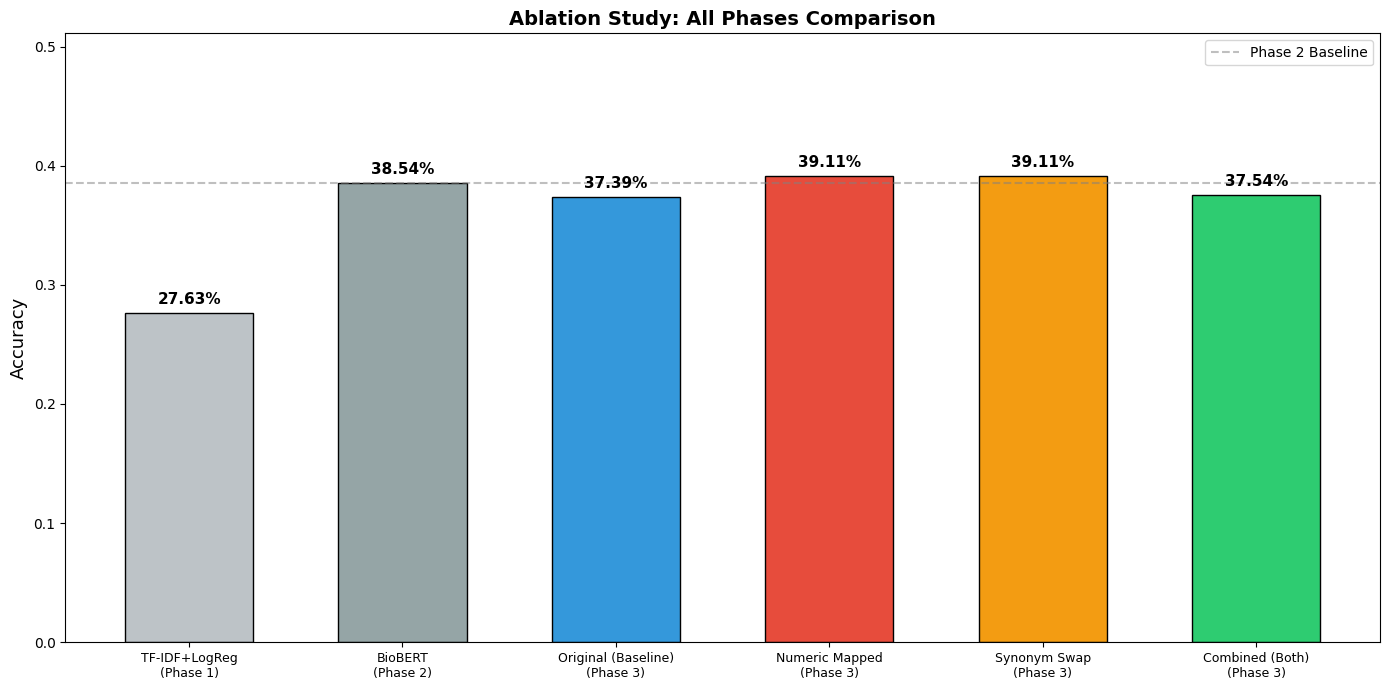

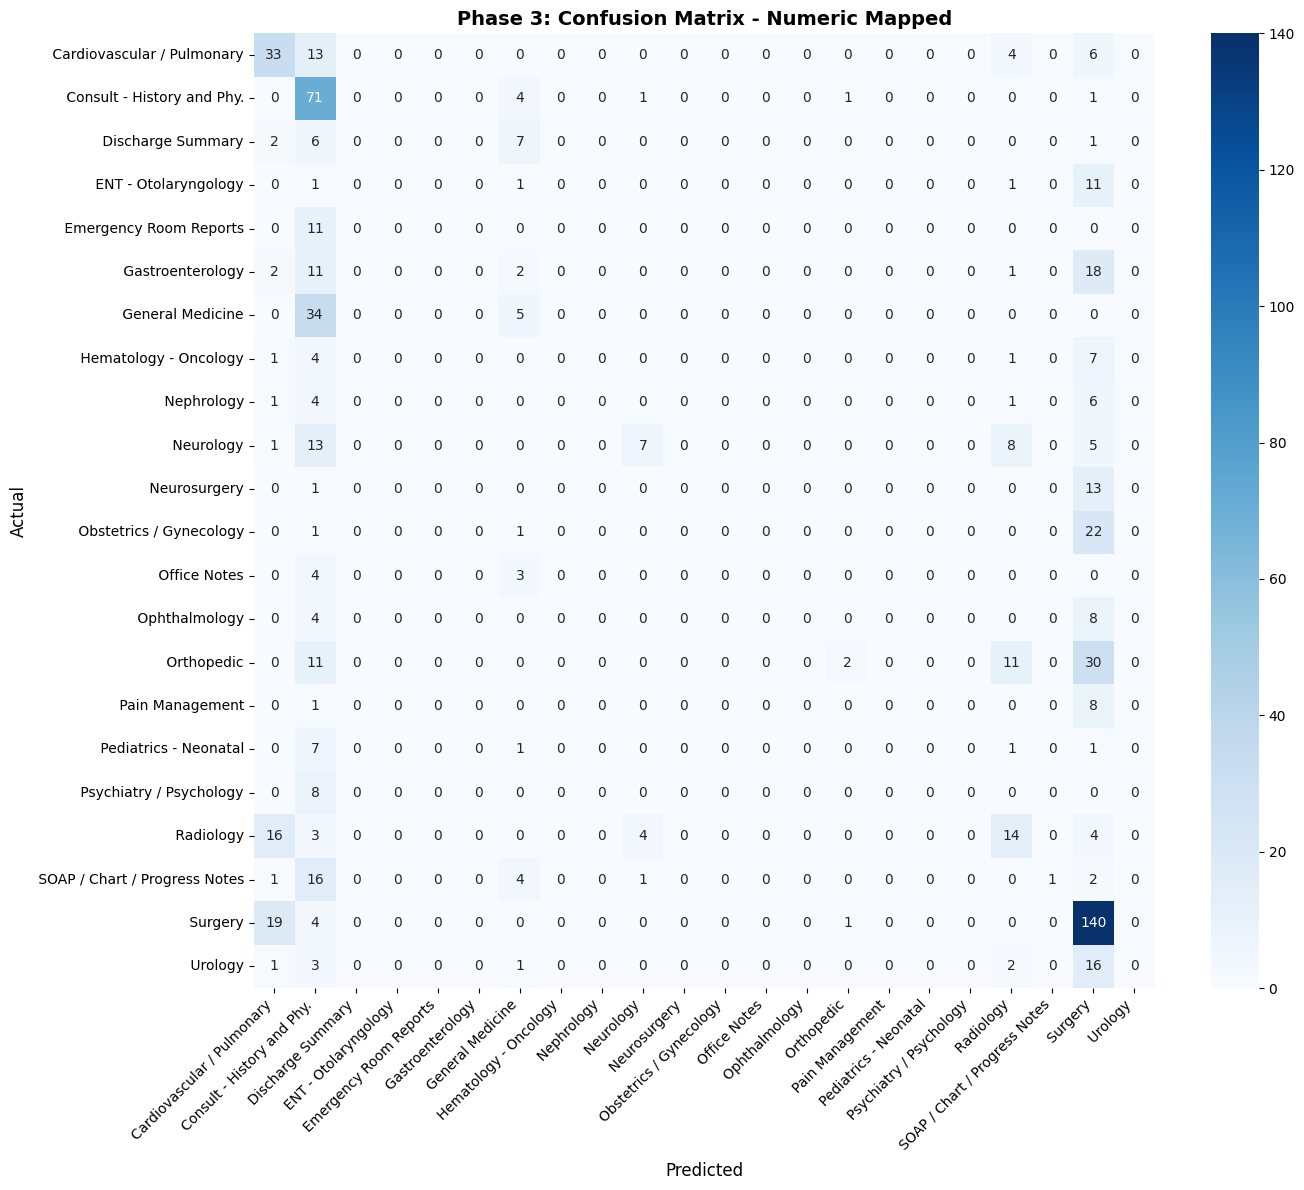

Phase 3 figures saved!


In [15]:
# === SAVE ALL FIGURES ===
# Ablation comparison with all phases
all_results = {
    "TF-IDF+LogReg\n(Phase 1)": 0.2763,
    "BioBERT\n(Phase 2)": 0.3854,
}
for name, result in ablation_results.items():
    display_name = name + "\n(Phase 3)"
    all_results[display_name] = result["accuracy"]

names = list(all_results.keys())
accs = list(all_results.values())
colors = ["#bdc3c7", "#95a5a6", "#3498db", "#e74c3c", "#f39c12", "#2ecc71"]

plt.figure(figsize=(14, 7))
bars = plt.bar(range(len(names)), accs, color=colors[:len(names)], edgecolor="black", width=0.6)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
             "{:.2f}%".format(acc * 100), ha="center", va="bottom", fontweight="bold", fontsize=11)
plt.xticks(range(len(names)), names, fontsize=9)
plt.ylabel("Accuracy", fontsize=13)
plt.title("Ablation Study: All Phases Comparison", fontsize=14, fontweight="bold")
plt.ylim(0, max(accs) + 0.12)
plt.axhline(y=0.3854, color="gray", linestyle="--", alpha=0.5, label="Phase 2 Baseline")
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig("phase3_ablation_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion matrix for best
best_name = max(ablation_results, key=lambda x: ablation_results[x]["accuracy"])
best_result = ablation_results[best_name]
_, _, test_ds_best = datasets_dict[best_name]
cm = confusion_matrix(test_ds_best["label"], best_result["predictions"])
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Phase 3: Confusion Matrix - " + best_name, fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("phase3_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Phase 3 figures saved!")